# 04 — Budget Scenarios

## Overview

This notebook uses the saved directional model to create 0%–200% response curves and score five bounded weekly budget scenarios. It exports both detailed allocations and a compact comparison while retaining explicit extrapolation and non-causality caveats.

## Context & Methods

Run Notebooks 01–03 first. Response curves vary one channel while holding other recent inputs representative. Scenarios use current recent weekly budgets, cap every channel at twice its historical active-week mean, and preserve total budget for Digital Focus and ROI Reallocation.

### Key Assumptions

- Response curves are model sensitivities, not experimental dose-response estimates.
- Scenario budgets remain between 0% and 200% of each channel's historical active-week mean.
- Digital Focus and ROI Reallocation preserve the Current total weekly budget; the reduction and TV-cut cases intentionally do not.
- Predictions are directional and synthetic-data based. Moving beyond observed support increases extrapolation risk even inside the explicit bounds.

### 1. Set Up the Project Path

In [1]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = (
    working_directory.parent
    if working_directory.name.lower() == "notebooks"
    else working_directory
)
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError(
        "Launch this notebook from the project root or the notebooks directory."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\yifei\Workspace\marketing-mmm-python\.worktrees\mmm-implementation


In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import get_project_paths
from src.scenarios import (
    build_response_curves,
    create_budget_scenarios,
    score_budget_scenarios,
)
from src.visualization import (
    plot_response_curves,
    plot_scenario_comparison,
)

paths = get_project_paths(PROJECT_ROOT)
paths.charts.mkdir(parents=True, exist_ok=True)
paths.reports.mkdir(parents=True, exist_ok=True)

## Data

### 2. Load the Prepared Data, Model, and Channel Summary

In [3]:
modelling_path = paths.processed / "modelling_ready_data.csv"
bundle_path = paths.model / "model_bundle.joblib"
channel_summary_path = paths.reports / "channel_summary.csv"
required_paths = [modelling_path, bundle_path, channel_summary_path]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Run Notebooks 01–03 first. Missing: "
        + ", ".join(str(path.relative_to(PROJECT_ROOT)) for path in missing_paths)
    )

modelling_data = pd.read_csv(modelling_path, parse_dates=["date"])
model_bundle = joblib.load(bundle_path)
channel_summary = pd.read_csv(channel_summary_path)
required_summary_columns = {
    "channel", "historical_active_mean", "current_weekly_budget", "proxy_roi"
}
assert required_summary_columns.issubset(channel_summary.columns)

display(channel_summary[
    ["channel", "historical_active_mean", "current_weekly_budget", "proxy_roi"]
].round(3))

,channel,historical_active_mean,current_weekly_budget,proxy_roi
0,google_ads_spend,93215.969,29310.000,10.144
1,instagram_spend,71951.069,71049.231,12.351
2,ott_spend,57737.044,56830.769,8.498
3,tv_spend,51779.276,53427.692,7.458
4,youtube_spend,41590.903,29692.308,5.852
5,influencer_spend,31374.800,14886.154,13.718
6,newspaper_spend,7376.897,5162.308,34.593


## Results

### 3. Build and Export Response Curves

In [4]:
response_curves = build_response_curves(
    model_bundle, modelling_data, points=21
)

In [5]:
response_curves.to_csv(paths.reports / "response_curves.csv", index=False)

In [6]:
response_checkpoints = response_curves.loc[
    np.isclose(response_curves["spend_multiplier"], 0.0)
    | np.isclose(response_curves["spend_multiplier"], 1.0)
    | np.isclose(response_curves["spend_multiplier"], 2.0)
]

In [7]:
display(response_checkpoints.round(3))

,channel,spend_multiplier,weekly_spend,predicted_sales,incremental_predicted_sales
0,instagram_spend,0.0,0.000,1684830.901,0.000
10,instagram_spend,1.0,71049.231,2483493.591,798662.690
20,instagram_spend,2.0,142098.462,2642851.960,958021.059
21,google_ads_spend,0.0,0.000,2001930.123,0.000
31,google_ads_spend,1.0,29310.000,2483493.591,481563.468
41,google_ads_spend,2.0,58620.000,2684627.848,682697.725
42,tv_spend,0.0,0.000,2139718.741,0.000
52,tv_spend,1.0,53427.692,2483493.591,343774.850
62,tv_spend,2.0,106855.385,2545462.043,405743.301
63,youtube_spend,0.0,0.000,2294594.286,0.000


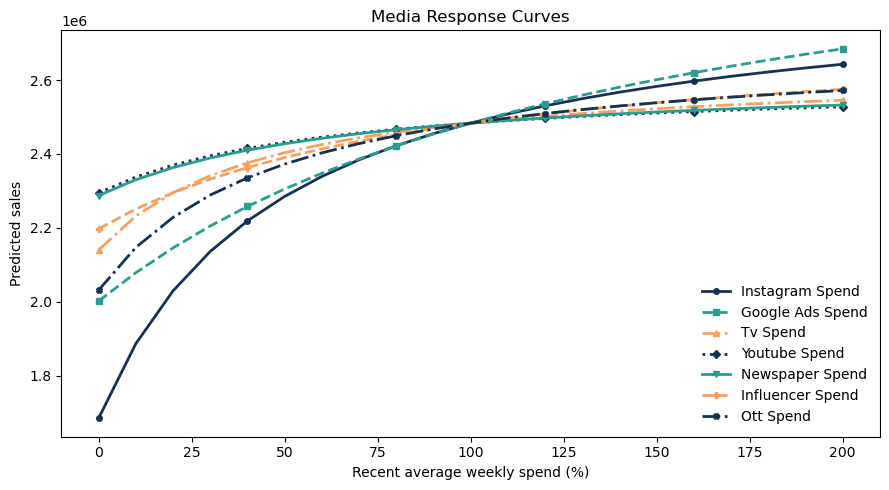

In [8]:
response_curve_path = paths.charts / "media_response_curves.png"
axes = plot_response_curves(response_curves, response_curve_path)
line_styles = ["-", "--", "-.", ":", "-", "--", "-."]
markers = ["o", "s", "^", "D", "v", "P", "X"]
for index, line in enumerate(axes.lines):
    line.set_linestyle(line_styles[index])
    line.set_marker(markers[index])
    line.set_markevery(4)
    line.set_markersize(4)
axes.set_xlabel("Recent average weekly spend (%)")
axes.legend(frameon=False)
axes.figure.tight_layout()
axes.figure.savefig(response_curve_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(axes.figure)

### 4. Create, Validate, and Score Five Scenarios

In [9]:
scenario_allocations = create_budget_scenarios(channel_summary)
scenario_results = score_budget_scenarios(
    model_bundle, modelling_data, scenario_allocations
)

In [10]:
allocation_totals = scenario_allocations.groupby("scenario", sort=False)[
    "weekly_budget"
].sum()
current_total = allocation_totals.loc["Current"]
assert np.isclose(allocation_totals.loc["Digital Focus"], current_total)
assert np.isclose(allocation_totals.loc["ROI Reallocation"], current_total)
assert (scenario_allocations["weekly_budget"] >= 0).all()
assert (
    scenario_allocations["weekly_budget"]
    <= scenario_allocations["historical_active_mean"] * 2.0 + 1e-12
).all()

In [11]:
scenario_allocations.to_csv(
    paths.reports / "budget_scenario_allocations.csv", index=False
)
scenario_results.to_csv(
    paths.reports / "budget_scenarios.csv", index=False
)

In [12]:
allocation_pivot = scenario_allocations.pivot(
    index="scenario", columns="channel", values="weekly_budget"
).reindex(scenario_results["scenario"])

In [13]:
display(allocation_pivot.round(1))
display(scenario_results.round(3))

channel,google_ads_spend,influencer_spend,instagram_spend,newspaper_spend,ott_spend,tv_spend,youtube_spend
scenario,,,,,,,
Current,29310.0,14886.2,71049.2,5162.3,56830.8,53427.7,29692.3
20% Budget Reduction,23448.0,11908.9,56839.4,4129.8,45464.6,42742.2,23753.8
Digital Focus,35172.0,17863.4,85259.1,1606.8,68196.9,16629.5,35630.8
TV Cut,29310.0,14886.2,71049.2,5162.3,56830.8,26713.8,29692.3
ROI Reallocation,29310.0,47420.3,71049.2,11681.9,56830.8,28324.8,15741.4


,scenario,total_weekly_budget,predicted_sales,predicted_sales_change,predicted_sales_change_pct
0,Current,260358.462,2592496.005,0.000,0.000
1,20% Budget Reduction,208286.769,2347382.962,-245113.043,-9.455
2,Digital Focus,260358.462,2523830.866,-68665.139,-2.649
3,TV Cut,233644.615,2513632.356,-78863.650,-3.042
4,ROI Reallocation,260358.462,2668465.808,75969.802,2.930


In [14]:
current_result = scenario_results.loc[
    scenario_results["scenario"] == "Current"
].iloc[0]
best_result = scenario_results.sort_values(
    "predicted_sales", ascending=False
).iloc[0]
display(Markdown(
    f"**Finding.** **{best_result['scenario']}** has the highest modeled weekly sales "
    f"({best_result['predicted_sales']:,.0f}), a "
    f"**{best_result['predicted_sales_change_pct']:+.2f}%** change from Current at "
    f"{current_result['total_weekly_budget']:,.0f} weekly budget. "
    "**Business meaning.** The comparison identifies a direction to investigate, not an "
    "automatic allocation decision. **Caution.** Scenario differences inherit model error, "
    "synthetic-data limitations, and extrapolation risk."
))

**Finding.** **ROI Reallocation** has the highest modeled weekly sales (2,668,466), a **+2.93%** change from Current at 260,358 weekly budget. **Business meaning.** The comparison identifies a direction to investigate, not an automatic allocation decision. **Caution.** Scenario differences inherit model error, synthetic-data limitations, and extrapolation risk.

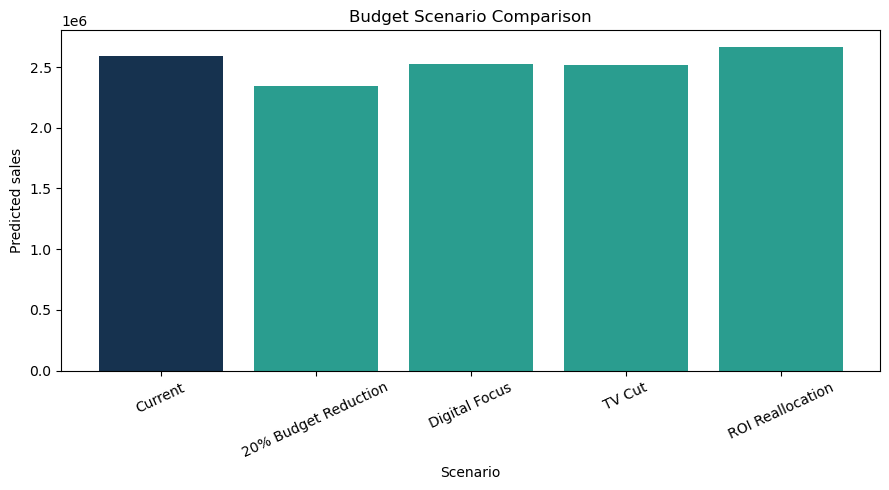

In [15]:
axes = plot_scenario_comparison(
    scenario_results, paths.charts / "budget_scenario_comparison.png"
)
plt.show()
plt.close(axes.figure)

### 5. Check Marginal Direction at the Upper Bound

In [16]:
curve_pivot = response_curves.pivot(
    index="spend_multiplier", columns="channel", values="predicted_sales"
)
upper_change = (
    curve_pivot.loc[2.0] - curve_pivot.loc[1.0]
).sort_values(ascending=False)
upper_change_table = upper_change.rename(
    "predicted_sales_change_from_100_to_200_percent"
).reset_index()
display(upper_change_table.round(2))

strongest_upper_change = upper_change_table.iloc[0]
display(Markdown(
    f"**Finding.** The largest modeled change from 100% to the 200% bound is for "
    f"**{strongest_upper_change['channel'].replace('_', ' ').title()}** "
    f"({strongest_upper_change['predicted_sales_change_from_100_to_200_percent']:+,.0f} sales). "
    "**Business meaning.** This is a sensitivity signal for further testing. "
    "**Caution.** The 200% point is the explicit extrapolation boundary and may be far from "
    "the channel's recent operating level."
))

,channel,predicted_sales_change_from_100_to_200_percent
0,google_ads_spend,201134.26
1,instagram_spend,159358.37
2,influencer_spend,91612.80
3,ott_spend,88351.86
4,tv_spend,61968.45
5,newspaper_spend,49042.88
6,youtube_spend,44324.19


**Finding.** The largest modeled change from 100% to the 200% bound is for **Google Ads Spend** (+201,134 sales). **Business meaning.** This is a sensitivity signal for further testing. **Caution.** The 200% point is the explicit extrapolation boundary and may be far from the channel's recent operating level.

## Takeaways

- All five scenarios are non-negative and bounded by historical activity; the two reallocation cases preserve the Current total budget.
- Response curves and scenario rankings are practical sensitivity views, not forecasts with uncertainty intervals or causal recommendations.
- A real planning decision should add experimental calibration, uncertainty ranges, operational constraints, and stakeholder review before moving spend.